<a href="https://colab.research.google.com/github/cjimenez275/Machine_learning/blob/main/K_vecinos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-vecinos mas cercanos
Para un conjunto de datos en una diagrama de dispersión se puede predecir una nueva entrada trazando una línea en el valor x deseado y encontrado los k puntos mas cercanos a la línea, el valor predicho será el promedio de los k valores de y, para los k puntos.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsRegressor
carros = pd.read_csv("carros.csv")
carros;

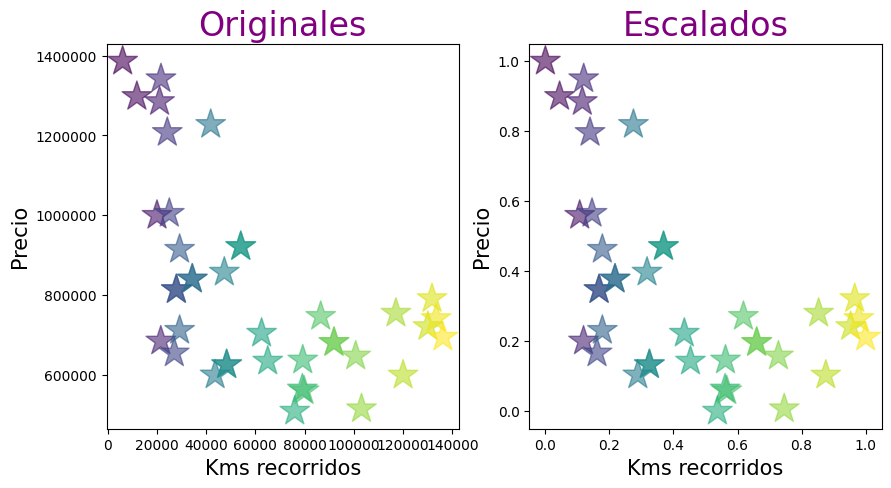

In [11]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,2,1)
ax.scatter(carros["kms"], carros["precio"],
            marker="*", s=500, c=range(carros["kms"].size), alpha=0.6)

ax.set_title("Originales", size=24, color="purple")
ax.set_ylabel("Precio", size=15)
ax.set_xlabel("Kms recorridos", size=15)
ax.ticklabel_format(style="plain")

#Escalamiento de datos
escala_kms = preprocessing.MinMaxScaler()
escala_precio = preprocessing.MinMaxScaler()
kms = escala_kms.fit_transform(carros["kms"].values.reshape(-1,1))
precio = escala_precio.fit_transform(carros["precio"].values.reshape(-1,1))

#Graficar datos escalados
ax = fig.add_subplot(1,2,2)
ax.scatter(kms, precio,
            marker="*", s=500, c=range(kms.size), alpha=0.6)
ax.set_title("Escalados", size=24, color="purple")
ax.set_ylabel("Precio", size=15)
ax.set_xlabel("Kms recorridos", size=15)
ax.ticklabel_format(style="plain")
plt.show()

Ahora realizamos el ajuste con los k vecinos mas cercanos para predecir el valor de un dato nuevo

In [10]:
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(kms, precio)

kms_instancia = escala_kms.transform([[20000]])
precio_instancia = knn.predict(kms_instancia)

escala_precio.inverse_transform(precio_instancia)

array([[990048.]])

Precio de carros de 0 a 140.000 kms

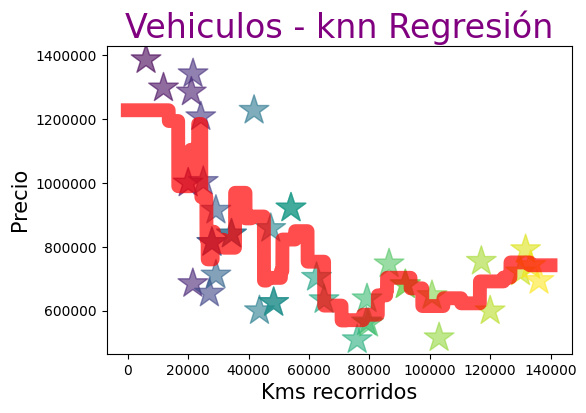

In [17]:
kms_instancia = escala_kms.transform(np.arange(140000).reshape(-1,1))
precio_instancia = knn.predict(kms_instancia)
todas = escala_precio.inverse_transform(precio_instancia)
todas = todas.reshape(1, -1)

# Graficar
fig = plt.figure(figsize=(6, 4))
plt.plot(np.arange(140000), todas.reshape(1, -1)[0],
         linewidth=10, color="red", alpha=0.7)
plt.scatter(carros["kms"], carros["precio"], marker="*",
            s=500, c=range(carros["kms"].size), alpha=0.6)

plt.title("Vehiculos - knn Regresión", size=24, color="purple")
plt.ylabel("Precio", size=15)
plt.xlabel("Kms recorridos", size=15)
plt.ticklabel_format(style="plain")
plt.show()